In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_validate
from model_pipelines import ModelConstructor

In [2]:
plt.rcParams['figure.dpi'] = 300

In [3]:
target_class_labels = ['Dropout', 'Enrolled', 'Graduated']

### Model A: Early detection

In [4]:
model_A = ModelConstructor('A')
pipelines_A = model_A.fetch_pipelines('xgb')

X_train, X_test, y_train, y_test = model_A.fetch_splits()

In [5]:
model_A = ModelConstructor('A')
pipelines_A = model_A.fetch_pipelines('xgb')

cv_A = {}
for key, pipeline in pipelines_A.items():
    X_train, X_test, y_train, y_test = model_A.fetch_splits()
    cv = cross_validate(
        pipeline, X_train, y_train,
        cv=5, scoring='f1_macro', return_estimator=True,
    )
    cv_A[key] = cv

In [6]:
cv_mean_A = [x['test_score'].mean() for x in cv_A.values()]
cv_std_A = [x['test_score'].std() for x in cv_A.values()]

tp_A = {
    x[0]: np.where(x[1]['test_score']==x[1]['test_score'].max())[0][0]
    for x in cv_A.items()
}

test_scores_A = []
for key, val in tp_A.items():
    test_scores_A.append(
        cv_A[key]['estimator'][val].score(X_test, y_test, scoring = 'f1_macro')
    )

confusion_matrices_A = []
classification_reports_A = []
for key, val in tp_A.items():
    Y_pred = cv_A[key]['estimator'][val].predict(X_test)
    cm = confusion_matrix(y_test, Y_pred)
    confusion_matrices_A.append(cm)
    cr = classification_report(Y_pred, y_test, target_names = target_class_labels, output_dict=True)
    classification_reports_A.append(cr)

Text(0.5, 1.0, 'Model A - Early detection')

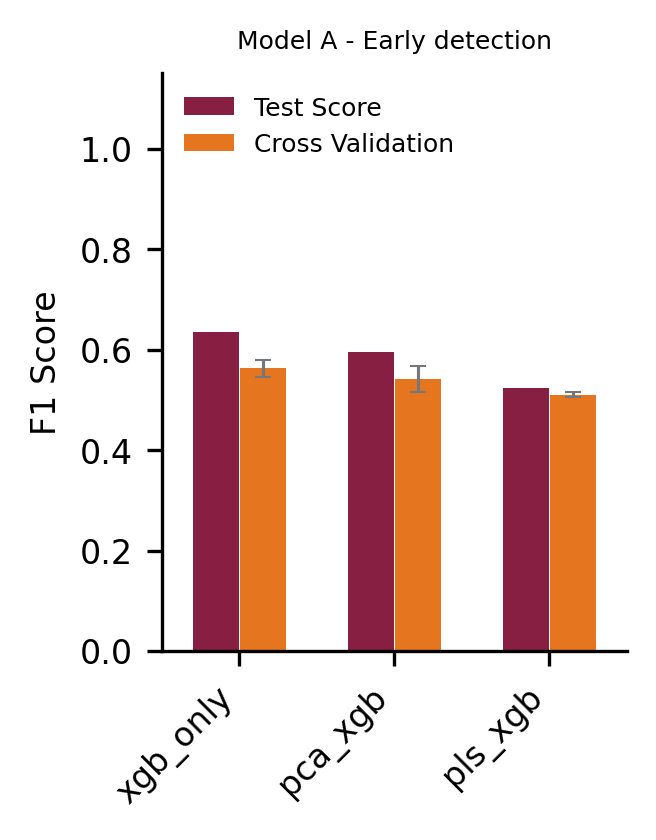

In [7]:
fig, ax = plt.subplots(figsize = (2,2.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = 8)
labels = ['xgb_only', 'pca_xgb', 'pls_xgb']
[1,3,5]
ax.bar(
    [1.2,3.2,5.2],
    test_scores_A,
    width=0.59,
    color = '#861F41',
    label = 'Test Score'
)
ax.bar(
    [1.8,3.8,5.8],
    cv_mean_A,
    width=0.59,
    color = '#E5751F',
    label = 'Cross Validation'
)

ax.errorbar(
    [1.8,3.8,5.8],
    cv_mean_A,
    cv_std_A,
    fmt='o',
    markersize = 0,
    color = '#75787b',
    elinewidth = 0.75,
    capsize = 2,
    capthick=0.5
)

ax.legend(fontsize = 6, frameon = False, loc = 'upper left')
ax.set_xticks([1.5,3.5,5.5])
ax.set_xticklabels(labels, fontsize = 8, rotation = 45, ha = 'right')
ax.set_xlim(0.5,6.5)
ax.set_ylim(0,1.15)
ax.set_ylabel("F1 Score", fontsize = 8)
ax.set_title("Model A - Early detection", fontsize = 6)

### Model B: Enrolled detection

In [8]:
model_B = ModelConstructor('B')
pipelines_B = model_B.fetch_pipelines('xgb')

X_train, X_test, y_train, y_test = model_B.fetch_splits()
cv_B = {}
for key, pipeline in pipelines_B.items():
    cv = cross_validate(
        pipeline, X_train, y_train,
        cv=5, scoring='f1_macro', return_estimator=True,
    )
    cv_B[key] = cv

In [9]:
cv_mean_B = [x['test_score'].mean() for x in cv_B.values()]
cv_std_B = [x['test_score'].std() for x in cv_B.values()]

tp_B = {
    x[0]: np.where(x[1]['test_score']==x[1]['test_score'].max())[0][0]
    for x in cv_B.items()
}

test_scores_B = []
for key, val in tp_B.items():
    test_scores_B.append(
        cv_B[key]['estimator'][val].score(X_test, y_test, scoring = 'f1_macro')
    )

confusion_matrices_B = []
classification_reports_B = []
for key, val in tp_B.items():
    Y_pred = cv_B[key]['estimator'][val].predict(X_test)
    cm = confusion_matrix(y_test, Y_pred)
    confusion_matrices_B.append(cm)
    cr = classification_report(Y_pred, y_test, target_names = target_class_labels, output_dict=True)
    classification_reports_B.append(cr)

Text(0.5, 1.0, 'Model B - Enrolled detection')

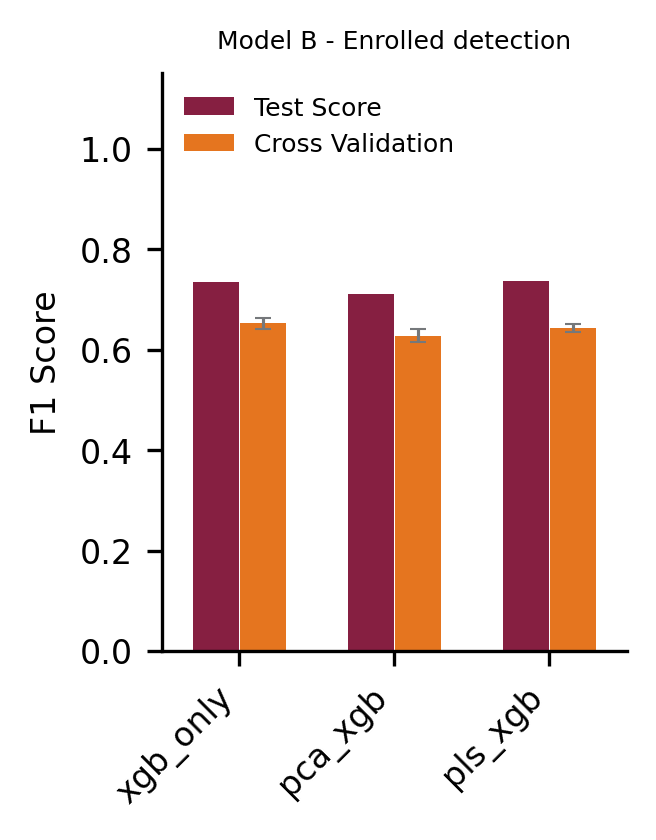

In [10]:
fig, ax = plt.subplots(figsize = (2,2.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = 8)
labels = ['xgb_only', 'pca_xgb', 'pls_xgb']
[1,3,5]
ax.bar(
    [1.2,3.2,5.2],
    test_scores_B,
    width=0.59,
    color = '#861F41',
    label = 'Test Score'
)
ax.bar(
    [1.8,3.8,5.8],
    cv_mean_B,
    width=0.59,
    color = '#E5751F',
    label = 'Cross Validation'
)

ax.errorbar(
    [1.8,3.8,5.8],
    cv_mean_B,
    cv_std_B,
    fmt='o',
    markersize = 0,
    color = '#75787b',
    elinewidth = 0.75,
    capsize = 2,
    capthick=0.5
)

ax.legend(fontsize = 6, frameon = False, loc = 'upper left')
ax.set_xticks([1.5,3.5,5.5])
ax.set_xticklabels(labels, fontsize = 8, rotation = 45, ha = 'right')
ax.set_xlim(0.5,6.5)
ax.set_ylim(0,1.15)
ax.set_ylabel("F1 Score", fontsize = 8)
ax.set_title("Model B - Enrolled detection", fontsize = 6)

### Model C: Combined pre-and post enrollment detection

In [11]:
model_C = ModelConstructor('C')
pipelines_C = model_C.fetch_pipelines('xgb')

X_train, X_test, y_train, y_test = model_C.fetch_splits()
cv_C = {}
for key, pipeline in pipelines_C.items():
    cv = cross_validate(
        pipeline, X_train, y_train,
        cv=5, scoring='f1_macro', return_estimator=True,
    )
    cv_C[key] = cv

In [12]:
cv_mean_C = [x['test_score'].mean() for x in cv_C.values()]
cv_std_C = [x['test_score'].std() for x in cv_C.values()]

tp_C = {
    x[0]: np.where(x[1]['test_score']==x[1]['test_score'].max())[0][0]
    for x in cv_C.items()
}

test_scores_C = []
for key, val in tp_C.items():
    test_scores_C.append(
        cv_C[key]['estimator'][val].score(X_test, y_test, scoring = 'f1_macro')
    )

confusion_matrices_C = []
classification_reports_C = []
for key, val in tp_C.items():
    Y_pred = cv_C[key]['estimator'][val].predict(X_test)
    cm = confusion_matrix(y_test, Y_pred)
    confusion_matrices_C.append(cm)
    cr = classification_report(Y_pred, y_test, target_names = target_class_labels, output_dict=True)
    classification_reports_C.append(cr)

Text(0.5, 1.0, 'Model C - Combined detection')

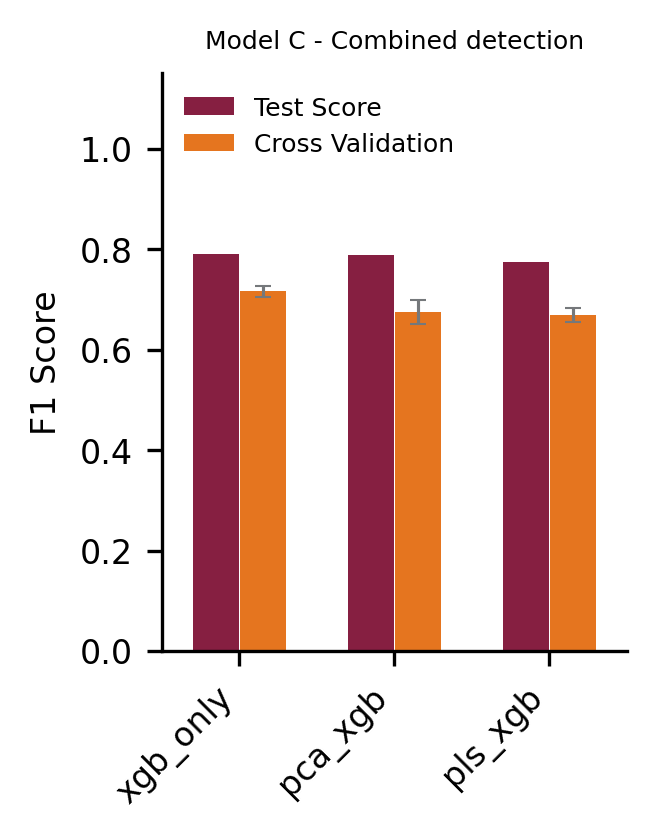

In [13]:
fig, ax = plt.subplots(figsize = (2,2.5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = 8)
labels = ['xgb_only', 'pca_xgb', 'pls_xgb']
[1,3,5]
ax.bar(
    [1.2,3.2,5.2],
    test_scores_C,
    width=0.59,
    color = '#861F41',
    label = 'Test Score'
)
ax.bar(
    [1.8,3.8,5.8],
    cv_mean_C,
    width=0.59,
    color = '#E5751F',
    label = 'Cross Validation'
)

ax.errorbar(
    [1.8,3.8,5.8],
    cv_mean_C,
    cv_std_C,
    fmt='o',
    markersize = 0,
    color = '#75787b',
    elinewidth = 0.75,
    capsize = 2,
    capthick=0.5
)

ax.legend(fontsize = 6, frameon = False, loc = 'upper left')
ax.set_xticks([1.5,3.5,5.5])
ax.set_xticklabels(labels, fontsize = 8, rotation = 45, ha = 'right')
ax.set_xlim(0.5,6.5)
ax.set_ylim(0,1.15)
ax.set_ylabel("F1 Score", fontsize = 8)
ax.set_title("Model C - Combined detection", fontsize = 6)

### Performance Summary

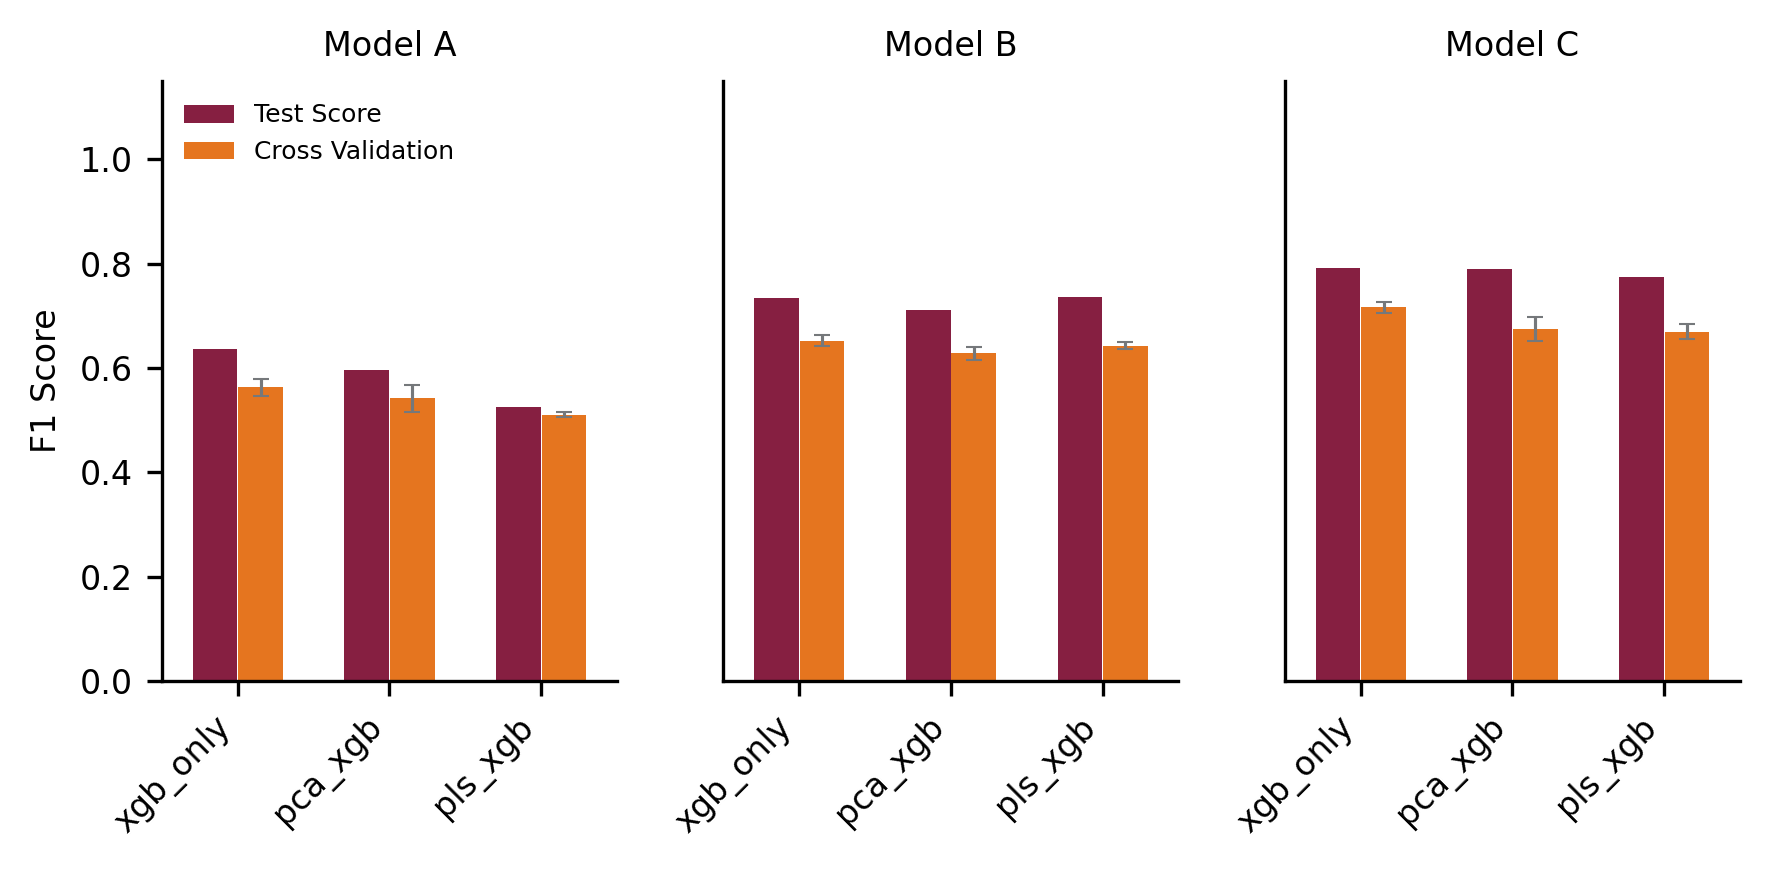

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(6, 3))

labels = ['xgb_only', 'pca_xgb', 'pls_xgb']

model_data = [
    {'test': test_scores_A, 'cv_mean': cv_mean_A, 'cv_std': cv_std_A, 'title': 'Model A'},
    {'test': test_scores_B, 'cv_mean': cv_mean_B, 'cv_std': cv_std_B, 'title': 'Model B'},
    {'test': test_scores_C, 'cv_mean': cv_mean_C, 'cv_std': cv_std_C, 'title': 'Model C'},
]

for i, (ax, data) in enumerate(zip(ax, model_data)):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=8)

    ax.bar(
        [1.2, 3.2, 5.2], 
        data['test'], 
        width=0.59, 
        color='#861F41', 
        label='Test Score'
    )

    ax.bar(
        [1.8, 3.8, 5.8], 
        data['cv_mean'], 
        width=0.59, 
        color='#E5751F', 
        label='Cross Validation'
    )

    ax.errorbar(
        [1.8, 3.8, 5.8], 
        data['cv_mean'], 
        data['cv_std'],
        fmt='o', 
        markersize=0, 
        color='#75787b',
        elinewidth=0.75, 
        capsize=2, 
        capthick=0.5
    )

    ax.set_xticks([1.5, 3.5, 5.5])
    ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
    ax.set_xlim(0.5, 6.5)
    ax.set_ylim(0, 1.15)
    ax.set_title(data['title'], fontsize=8)

    if i == 0:
        ax.set_ylabel("F1 Score", fontsize=8)
        ax.legend(fontsize=6, frameon=False, loc='upper left')
    else:
        ax.set_yticks([])

plt.tight_layout()

In [15]:
columns = ['Model', 'Architecture', 'CV_mean', 'CV_std', 'Test_score']
model_col = []
arch_col = []
models = ['A', 'B', 'C']
for i in range(3):
    model_col+=[models[i] for _ in range(3)]
    arch_col+=labels

data = [
    model_col,
    arch_col,
    cv_mean_A+cv_mean_B+cv_mean_C,
    cv_std_A+cv_std_B+cv_std_C,
    test_scores_A+test_scores_B+test_scores_C
]

cvdf = pd.DataFrame(np.array(data).T, columns=columns)
cvdf

,Model,Architecture,CV_mean,CV_std,Test_score
0,A,xgb_only,0.5628333793279794,0.016604530908100858,0.6361581920903955
1,A,pca_xgb,0.5417313090108657,0.025336315428449493,0.5954802259887005
2,A,pls_xgb,0.5105838422979426,0.004290240147533958,0.5242937853107345
3,B,xgb_only,0.6523502571341367,0.010989781955066474,0.7338044758539458
4,B,pca_xgb,0.6277994054903399,0.012410898340654153,0.7114252061248527
5,B,pls_xgb,0.6429571549447594,0.007296185097639753,0.7361601884570083
6,C,xgb_only,0.7159495476763426,0.010299090586388854,0.7915194346289752
7,C,pca_xgb,0.6749756379896767,0.02341378013569552,0.7891637220259128
8,C,pls_xgb,0.6694893834027078,0.014445399912454443,0.7750294464075382


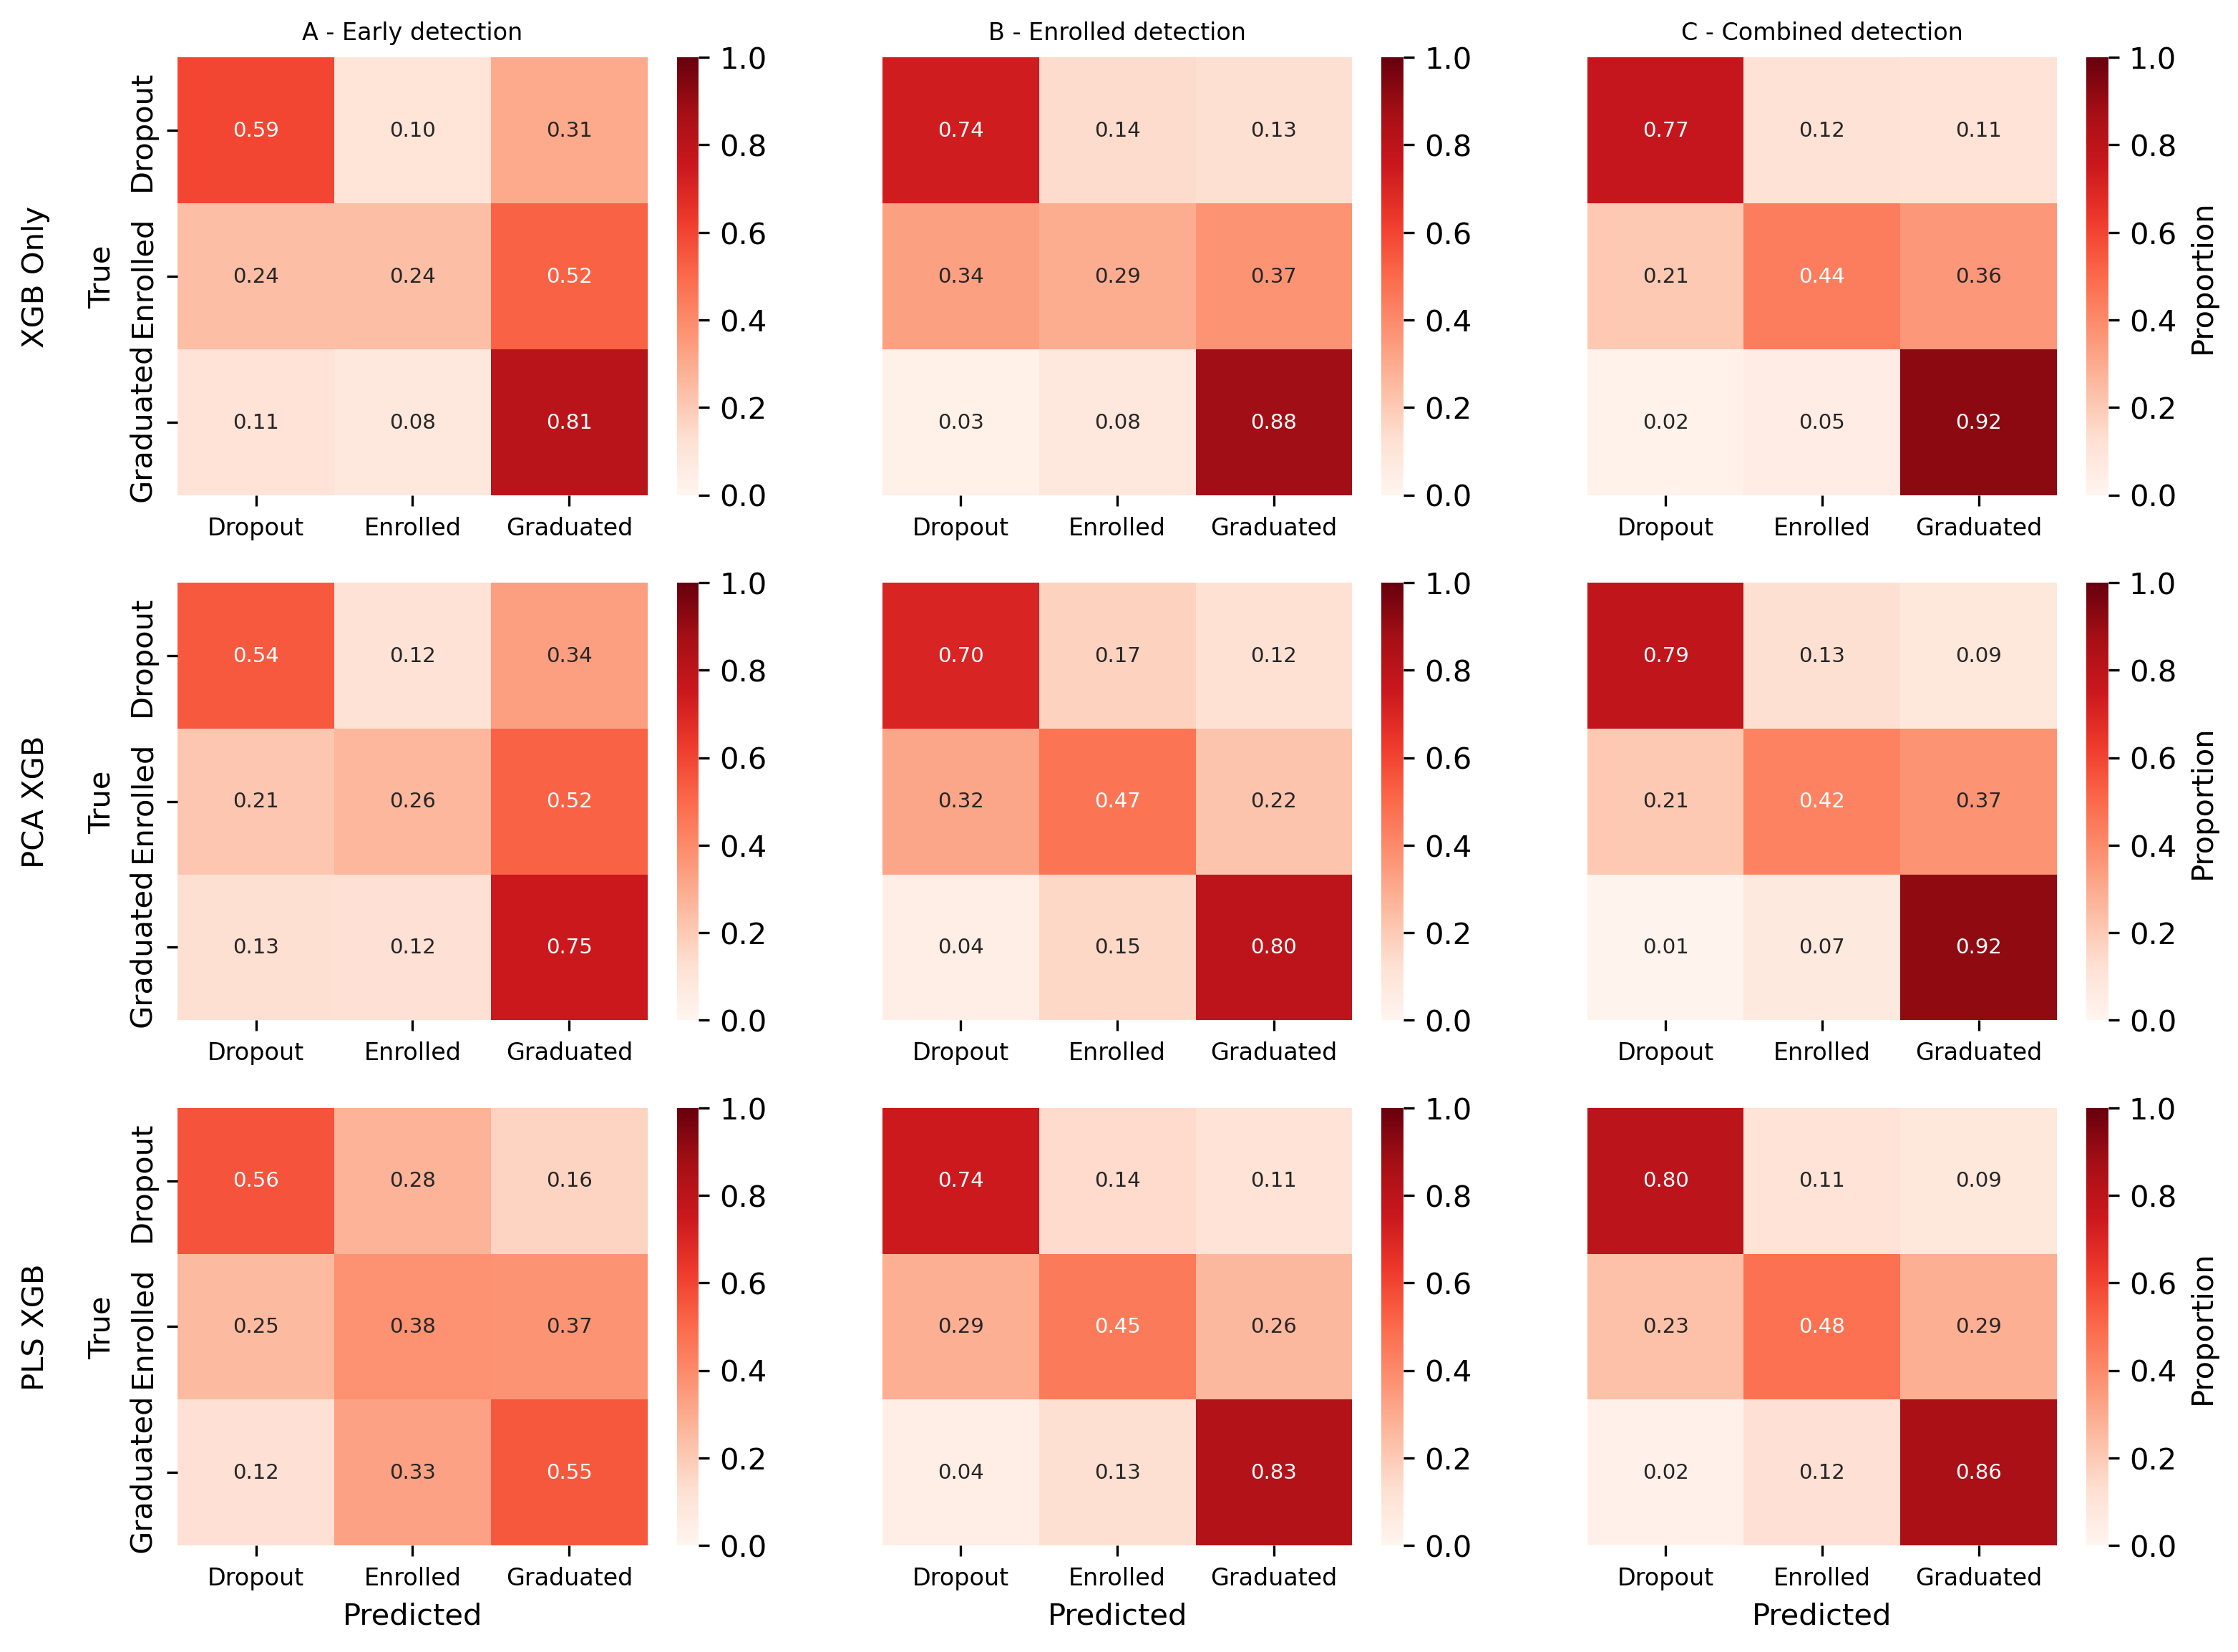

In [16]:
fig, ax = plt.subplots(3,3, figsize = (12,9))

model_labels = ['A - Early detection', 'B - Enrolled detection', 'C - Combined detection']
pipeline_labels = ['XGB Only', 'PCA XGB', 'PLS XGB']

for row in range(3):
    cmA = confusion_matrices_A[row]
    cmB = confusion_matrices_B[row]
    cmC = confusion_matrices_C[row]

    sns.heatmap(cmA/cmA.sum(axis=1, keepdims=True), ax = ax[row, 0], cmap = 'Reds', vmin = 0, vmax = 1, annot = True, fmt = '.2f', annot_kws = {'size': 7})
    sns.heatmap(cmB/cmB.sum(axis=1, keepdims=True), ax = ax[row, 1], cmap = 'Reds', vmin = 0, vmax = 1, annot = True, fmt = '.2f', annot_kws = {'size': 7})
    sns.heatmap(cmC/cmC.sum(axis=1, keepdims=True), ax = ax[row, 2], cmap = 'Reds', vmin = 0, vmax = 1, annot = True, fmt = '.2f', annot_kws = {'size': 7}, cbar_kws = {'label': 'Proportion'})

for row in range(3):
    for col in range(3):
        ax[row, col].tick_params(labelsize = 8)
        if row == 2:
            ax[row, col].set_xlabel("Predicted", fontsize = 10)
        if col>0:
            ax[row, col].set_yticks([])
        if col == 0:
            ax[row, col].set_yticklabels(target_class_labels, fontsize = 10)
            ax[row, col].set_ylabel(f"{pipeline_labels[row]}\n\nTrue", fontsize = 10)
        ax[row, col].set_xticklabels(target_class_labels, fontsize = 8)
        ax[0,col].set_title(model_labels[col], fontsize = 8)

In [17]:
crdf = pd.concat([
    pd.DataFrame(classification_reports_A[0]),
    pd.DataFrame(classification_reports_A[1]),
    pd.DataFrame(classification_reports_A[2]),
    pd.DataFrame(classification_reports_B[0]),
    pd.DataFrame(classification_reports_B[1]),
    pd.DataFrame(classification_reports_B[2]),
    pd.DataFrame(classification_reports_C[0]),
    pd.DataFrame(classification_reports_C[1]),
    pd.DataFrame(classification_reports_C[2]),
])

model_col = ['A']*12 + ['B']*12 + ['C']*12
arch_col_2 = []
for col in arch_col:
    arch_col_2+=[col]*4

crdf['Model'] = model_col
crdf['Architecture'] = arch_col_2
crdf = crdf.reset_index()
crdf = crdf[list(crdf.columns[-2:]) + list(crdf.columns[:-2])]
crdf.columns = ['Model', 'Architecture', 'Metric', 'Dropout', 'Enrolled', 'Graduated',
       'accuracy', 'macro avg', 'weighted avg']

In [18]:
table = pd.pivot_table(
    crdf, 
    values=list(crdf.columns[3:6]), 
    index=list(crdf.columns[:2]),
    columns=['Metric']
)
table

Dropout                              Enrolled            \
Metric              f1-score precision    recall support  f1-score precision   
Model Architecture                                                             
A     pca_xgb       0.600349  0.544304  0.669261   257.0  0.287770  0.264901   
      pls_xgb       0.609294  0.560127  0.667925   265.0  0.263279  0.377483   
      xgb_only      0.640545  0.594937  0.693727   271.0  0.288000  0.238411   
B     pca_xgb       0.726257  0.703971  0.750000   260.0  0.414634  0.465753   
      pls_xgb       0.757353  0.743682  0.771536   267.0  0.431373  0.452055   
      xgb_only      0.750000  0.736462  0.764045   267.0  0.326996  0.294521   
C     pca_xgb       0.822642  0.787004  0.861660   253.0  0.452555  0.424658   
      pls_xgb       0.817680  0.801444  0.834586   266.0  0.471380  0.479452   
      xgb_only      0.807547  0.772563  0.845850   253.0  0.483019  0.438356   

                                     Graduated                              
Metric                recall support  f1-score precision    recall support  
Model Architecture                                                          
A     pca_xgb       0.314961   127.0  0.685528  0.753589  0.628743   501.0  
      pls_xgb       0.202128   282.0  0.608466  0.550239  0.680473   338.0  
      xgb_only      0.363636    99.0  0.726688  0.811005  0.658252   515.0  
B     pca_xgb       0.373626   182.0  0.818727  0.800469  0.837838   407.0  
      pls_xgb       0.412500   160.0  0.832547  0.828638  0.836493   422.0  
      xgb_only      0.367521   117.0  0.843996  0.882629  0.808602   465.0  
C     pca_xgb       0.484375   128.0  0.872483  0.915493  0.833333   468.0  
      pls_xgb       0.463576   151.0  0.853147  0.859155  0.847222   432.0  
      xgb_only      0.537815   119.0  0.872647  0.924883  0.825996   477.0

### Save the models:

In [19]:
# ## save the models
# import joblib

# joblib.dump(
#     cv_A['pls_model']['estimator'][tp_A['pls_model']],
#     'pls_xgb_A.pkl'
# )

# joblib.dump(
#     cv_B['pls_model']['estimator'][tp_B['pls_model']],
#     'pls_xgb_B.pkl'
# )

# joblib.dump(
#     cv_C['pls_model']['estimator'][tp_C['pls_model']],
#     'pls_xgb_C.pkl'
# )
